In [0]:
patients_df = spark.read.csv(
    '/Volumes/hexa_databricks_7405607626929262/default/hexa_catalog/patients.csv',
    header=True,
    inferSchema=True
)

patients_df.printSchema()
display(patients_df)

root
 |-- patient_id: string (nullable = true)
 |-- patient_name: string (nullable = true)
 |-- city: string (nullable = true)
 |-- state: string (nullable = true)
 |-- age: integer (nullable = true)
 |-- gender: string (nullable = true)
 |-- insurance_status: string (nullable = true)



patient_id,patient_name,city,state,age,gender,insurance_status
P101,Rahul Sharma,Hyderabad,Telangana,35,Male,Active
P102,Priya Reddy,Bangalore,Karnataka,29,Female,Active
P103,Amit Kumar,Mumbai,Maharashtra,42,Male,Inactive
P104,Sneha Patel,Delhi,Delhi,31,Female,Active
P105,Farhan Ali,Chennai,Tamil Nadu,55,Male,Active
P106,Neha Singh,Pune,Maharashtra,38,Female,Inactive
P107,Arjun Verma,Hyderabad,Telangana,26,Male,Active
P108,Meera Nair,Kochi,Kerala,48,Female,Active


In [0]:
doctors_df = spark.read.csv(
    '/Volumes/hexa_databricks_7405607626929262/default/hexa_catalog/doctors.csv',
    header=True,
    inferSchema=True
)
doctors_df.printSchema()
display(doctors_df)

root
 |-- doctor_id: string (nullable = true)
 |-- doctor_name: string (nullable = true)
 |-- department: string (nullable = true)
 |-- city: string (nullable = true)
 |-- consultation_fee: integer (nullable = true)



doctor_id,doctor_name,department,city,consultation_fee
D101,Dr. Ramesh,Cardiology,Hyderabad,1500
D102,Dr. Priya,Neurology,Bangalore,2000
D103,Dr. Anita,Dermatology,Chennai,1000
D104,Dr. Suresh,Orthopedics,Mumbai,2500
D105,Dr. Meera,Pediatrics,Delhi,1200
D106,Dr. Kiran,Cardiology,Hyderabad,3000


In [0]:
appointments_df = spark.read.csv(
    '/Volumes/hexa_databricks_7405607626929262/default/hexa_catalog/appointments.csv',
    header=True,
    inferSchema=True
)
appointments_df.printSchema()
display(appointments_df)

root
 |-- appointment_id: string (nullable = true)
 |-- patient_id: string (nullable = true)
 |-- doctor_id: string (nullable = true)
 |-- appointment_date: date (nullable = true)
 |-- diagnosis: string (nullable = true)
 |-- bill_amount: integer (nullable = true)
 |-- status: string (nullable = true)



appointment_id,patient_id,doctor_id,appointment_date,diagnosis,bill_amount,status
A1001,P101,D101,2026-06-01,Heart Checkup,5000,Completed
A1002,P102,D102,2026-06-01,Migraine,3500,Completed
A1003,P103,D103,2026-06-02,Skin Allergy,2000,Pending
A1004,P104,D104,2026-06-02,Fracture,12000,Completed
A1005,P105,D105,2026-06-03,Fever,1500,Completed
A1006,P106,D106,2026-06-03,Heart Checkup,7000,Completed
A1007,P107,D101,2026-06-04,Chest Pain,5500,Completed
A1008,P108,D103,2026-06-04,Skin Infection,2500,Pending
A1009,P101,D106,2026-06-05,Cardiac Review,6500,Completed
A1010,P104,D104,2026-06-05,Back Pain,4500,Cancelled


In [0]:
preferences_df = spark.read.options(
    multiline=True
).json('/Volumes/hexa_databricks_7405607626929262/default/hexa_catalog/patient_preferences.json')
preferences_df.printSchema()
display(preferences_df)

root
 |-- contact: struct (nullable = true)
 |    |-- email: string (nullable = true)
 |    |-- phone: string (nullable = true)
 |-- patient_id: string (nullable = true)
 |-- preferred_hospital: string (nullable = true)



contact,patient_id,preferred_hospital
"List(rahul@mail.com, 9876500011)",P101,Apollo Hospital
"List(priya@mail.com, 9876500012)",P102,Yashoda Hospital
"List(sneha@mail.com, 9876500014)",P104,Care Hospital
"List(meera@mail.com, 9876500018)",P108,Apollo Hospital


In [0]:
patients_df.write.format('delta').mode('overwrite').save(
    '/Volumes/hexa_databricks_7405607626929262/default/hexa_catalog/bronze/patients'
)

doctors_df.write.format('delta').mode('overwrite').save(
    '/Volumes/hexa_databricks_7405607626929262/default/hexa_catalog/bronze/doctors'
)

appointments_df.write.format('delta').mode('overwrite').save(
    '/Volumes/hexa_databricks_7405607626929262/default/hexa_catalog/bronze/appointments'
)

preferences_df.write.format('delta').mode('overwrite').save(
    '/Volumes/hexa_databricks_7405607626929262/default/hexa_catalog/bronze/preferences'
)

In [0]:
from pyspark.sql.functions import *

patients_df.select([
        count(when(col(c).isNull(), c)).alias(c) for c in patients_df.columns
    ]).show()

doctors_df.select([
        count(when(col(c).isNull(), c)).alias(c) for c in doctors_df.columns
    ]).show()

appointments_df.select([
        count(when(col(c).isNull(), c)).alias(c) for c in appointments_df.columns
    ]).show()

preferences_df.select([
        count(when(col(c).isNull(), c)).alias(c) for c in preferences_df.columns
    ]).show()

+----------+------------+----+-----+---+------+----------------+
|patient_id|patient_name|city|state|age|gender|insurance_status|
+----------+------------+----+-----+---+------+----------------+
|         0|           0|   0|    0|  0|     0|               0|
+----------+------------+----+-----+---+------+----------------+

+---------+-----------+----------+----+----------------+
|doctor_id|doctor_name|department|city|consultation_fee|
+---------+-----------+----------+----+----------------+
|        0|          0|         0|   0|               0|
+---------+-----------+----------+----+----------------+

+--------------+----------+---------+----------------+---------+-----------+------+
|appointment_id|patient_id|doctor_id|appointment_date|diagnosis|bill_amount|status|
+--------------+----------+---------+----------------+---------+-----------+------+
|             0|         0|        0|               0|        0|          0|     0|
+--------------+----------+---------+---------------

In [0]:
flat = preferences_df.select(
    col("patient_id"),
    col("preferred_hospital"),
    col("contact.phone").alias("phone"),
    col("contact.email").alias("email")
)
display(flat)

patient_id,preferred_hospital,phone,email
P101,Apollo Hospital,9876500011,rahul@mail.com
P102,Yashoda Hospital,9876500012,priya@mail.com
P104,Care Hospital,9876500014,sneha@mail.com
P108,Apollo Hospital,9876500018,meera@mail.com


In [0]:
patients = patients_df.withColumnRenamed(
    "city",
    "patient_city"
)
doctors = doctors_df.withColumnRenamed(
    "city",
    "doctor_city"
)

In [0]:
patient_pref_df = patients.join(
    flat,
    "patient_id",
    "left"
)
patient_pref_df.show()

patient_appointments_df = appointments_df.join(
    patients,
    on="patient_id",
    how="inner"
)
patient_appointments_df.show()

healthcare_df = patient_appointments_df.join(
    doctors,
    on="doctor_id",
    how="inner"
)
healthcare_df.show()

+----------+------------+------------+-----------+---+------+----------------+------------------+----------+--------------+
|patient_id|patient_name|patient_city|      state|age|gender|insurance_status|preferred_hospital|     phone|         email|
+----------+------------+------------+-----------+---+------+----------------+------------------+----------+--------------+
|      P101|Rahul Sharma|   Hyderabad|  Telangana| 35|  Male|          Active|   Apollo Hospital|9876500011|rahul@mail.com|
|      P102| Priya Reddy|   Bangalore|  Karnataka| 29|Female|          Active|  Yashoda Hospital|9876500012|priya@mail.com|
|      P103|  Amit Kumar|      Mumbai|Maharashtra| 42|  Male|        Inactive|              NULL|      NULL|          NULL|
|      P104| Sneha Patel|       Delhi|      Delhi| 31|Female|          Active|     Care Hospital|9876500014|sneha@mail.com|
|      P105|  Farhan Ali|     Chennai| Tamil Nadu| 55|  Male|          Active|              NULL|      NULL|          NULL|
|      P

In [0]:
full_df = patients_df.join(
    preferences_df,
    'patient_id',
    'left'
).join(
    appointments_df,
    'patient_id',
    'left'
).join(
    doctors_df.withColumnRenamed('city', 'doctor_city'),
    'doctor_id',
    'left'
)

In [0]:
full_df = full_df.withColumn(
    "final_bill",
    col("bill_amount") + col("consultation_fee")
).withColumn(
    "appointment_month",
    date_format(
        to_date("appointment_date"),
        "yyyy-MM"
    )
).withColumn(
    "patient_age_group",
    when(col("age") >= 50, "Senior")
    .when(col("age") >= 30, "Adult")
    .otherwise("Young")
)

display(full_df)

doctor_id,patient_id,patient_name,city,state,age,gender,insurance_status,contact,preferred_hospital,appointment_id,appointment_date,diagnosis,bill_amount,status,doctor_name,department,doctor_city,consultation_fee,final_bill,appointment_month,patient_age_group
D106,P101,Rahul Sharma,Hyderabad,Telangana,35,Male,Active,"List(rahul@mail.com, 9876500011)",Apollo Hospital,A1009,2026-06-05,Cardiac Review,6500,Completed,Dr. Kiran,Cardiology,Hyderabad,3000,9500,2026-06,Adult
D102,P102,Priya Reddy,Bangalore,Karnataka,29,Female,Active,"List(priya@mail.com, 9876500012)",Yashoda Hospital,A1002,2026-06-01,Migraine,3500,Completed,Dr. Priya,Neurology,Bangalore,2000,5500,2026-06,Young
D103,P103,Amit Kumar,Mumbai,Maharashtra,42,Male,Inactive,null,null,A1003,2026-06-02,Skin Allergy,2000,Pending,Dr. Anita,Dermatology,Chennai,1000,3000,2026-06,Adult
D104,P104,Sneha Patel,Delhi,Delhi,31,Female,Active,"List(sneha@mail.com, 9876500014)",Care Hospital,A1010,2026-06-05,Back Pain,4500,Cancelled,Dr. Suresh,Orthopedics,Mumbai,2500,7000,2026-06,Adult
D105,P105,Farhan Ali,Chennai,Tamil Nadu,55,Male,Active,null,null,A1005,2026-06-03,Fever,1500,Completed,Dr. Meera,Pediatrics,Delhi,1200,2700,2026-06,Senior
D106,P106,Neha Singh,Pune,Maharashtra,38,Female,Inactive,null,null,A1006,2026-06-03,Heart Checkup,7000,Completed,Dr. Kiran,Cardiology,Hyderabad,3000,10000,2026-06,Adult
D101,P107,Arjun Verma,Hyderabad,Telangana,26,Male,Active,null,null,A1007,2026-06-04,Chest Pain,5500,Completed,Dr. Ramesh,Cardiology,Hyderabad,1500,7000,2026-06,Young
D103,P108,Meera Nair,Kochi,Kerala,48,Female,Active,"List(meera@mail.com, 9876500018)",Apollo Hospital,A1008,2026-06-04,Skin Infection,2500,Pending,Dr. Anita,Dermatology,Chennai,1000,3500,2026-06,Adult
D101,P101,Rahul Sharma,Hyderabad,Telangana,35,Male,Active,"List(rahul@mail.com, 9876500011)",Apollo Hospital,A1001,2026-06-01,Heart Checkup,5000,Completed,Dr. Ramesh,Cardiology,Hyderabad,1500,6500,2026-06,Adult
D104,P104,Sneha Patel,Delhi,Delhi,31,Female,Active,"List(sneha@mail.com, 9876500014)",Care Hospital,A1004,2026-06-02,Fracture,12000,Completed,Dr. Suresh,Orthopedics,Mumbai,2500,14500,2026-06,Adult


In [0]:
full_df.write.format('delta').mode('overwrite').save(
    '/Volumes/hexa_databricks_7405607626929262/default/hexa_catalog/silver/healthcare_data'
)

In [0]:
full_df.createOrReplaceTempView('healthcare')

In [0]:
%sql

SELECT
preferred_hospital,SUM(final_bill) as total_revenue
from healthcare
GROUP BY preferred_hospital;

preferred_hospital,total_revenue
Apollo Hospital,19500
Care Hospital,21500
Yashoda Hospital,5500
null,22700


In [0]:
%sql

SELECT department, SUM(final_bill) AS revenue
FROM healthcare
GROUP BY department
ORDER BY revenue DESC;

department,revenue
Cardiology,33000
Orthopedics,21500
Dermatology,6500
Neurology,5500
Pediatrics,2700


In [0]:
%sql
SELECT city, SUM(final_bill) AS revenue
FROM healthcare
GROUP BY city
ORDER BY revenue DESC;

city,revenue
Hyderabad,23000
Delhi,21500
Pune,10000
Bangalore,5500
Kochi,3500
Mumbai,3000
Chennai,2700


In [0]:
%sql
SELECT *
FROM healthcare
WHERE status='Completed';

doctor_id,patient_id,patient_name,city,state,age,gender,insurance_status,contact,preferred_hospital,appointment_id,appointment_date,diagnosis,bill_amount,status,doctor_name,department,doctor_city,consultation_fee,final_bill,appointment_month,patient_age_group
D106,P101,Rahul Sharma,Hyderabad,Telangana,35,Male,Active,"List(rahul@mail.com, 9876500011)",Apollo Hospital,A1009,2026-06-05,Cardiac Review,6500,Completed,Dr. Kiran,Cardiology,Hyderabad,3000,9500,2026-06,Adult
D102,P102,Priya Reddy,Bangalore,Karnataka,29,Female,Active,"List(priya@mail.com, 9876500012)",Yashoda Hospital,A1002,2026-06-01,Migraine,3500,Completed,Dr. Priya,Neurology,Bangalore,2000,5500,2026-06,Young
D104,P104,Sneha Patel,Delhi,Delhi,31,Female,Active,"List(sneha@mail.com, 9876500014)",Care Hospital,A1004,2026-06-02,Fracture,12000,Completed,Dr. Suresh,Orthopedics,Mumbai,2500,14500,2026-06,Adult
D105,P105,Farhan Ali,Chennai,Tamil Nadu,55,Male,Active,null,null,A1005,2026-06-03,Fever,1500,Completed,Dr. Meera,Pediatrics,Delhi,1200,2700,2026-06,Senior
D106,P106,Neha Singh,Pune,Maharashtra,38,Female,Inactive,null,null,A1006,2026-06-03,Heart Checkup,7000,Completed,Dr. Kiran,Cardiology,Hyderabad,3000,10000,2026-06,Adult
D101,P107,Arjun Verma,Hyderabad,Telangana,26,Male,Active,null,null,A1007,2026-06-04,Chest Pain,5500,Completed,Dr. Ramesh,Cardiology,Hyderabad,1500,7000,2026-06,Young
D101,P101,Rahul Sharma,Hyderabad,Telangana,35,Male,Active,"List(rahul@mail.com, 9876500011)",Apollo Hospital,A1001,2026-06-01,Heart Checkup,5000,Completed,Dr. Ramesh,Cardiology,Hyderabad,1500,6500,2026-06,Adult


In [0]:
%sql
SELECT patient_name, SUM(final_bill) AS total_billing
FROM healthcare
GROUP BY patient_name
ORDER BY total_billing DESC;

patient_name,total_billing
Sneha Patel,21500
Rahul Sharma,16000
Neha Singh,10000
Arjun Verma,7000
Priya Reddy,5500
Meera Nair,3500
Amit Kumar,3000
Farhan Ali,2700


In [0]:
from pyspark.sql.window import Window

doctor_rev = full_df.groupBy(
    "doctor_name"
).agg(sum("final_bill").alias("revenue"))

win_spec = Window.orderBy(doctor_rev["revenue"].desc())

doctor_rank = doctor_rev.withColumn(
    "rank",
    rank().over(win_spec)
)

display(doctor_rank)

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


doctor_name,revenue,rank
Dr. Suresh,21500,1
Dr. Kiran,19500,2
Dr. Ramesh,13500,3
Dr. Anita,6500,4
Dr. Priya,5500,5
Dr. Meera,2700,6


In [0]:
department_rev = full_df.groupBy(
    "department"
).agg(sum("final_bill").alias("revenue"))

win_spec = Window.orderBy(department_rev["revenue"].desc())

department_rank = department_rev.withColumn(
    "rank",
    rank().over(win_spec)
)

display(department_rank)

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


department,revenue,rank
Cardiology,33000,1
Orthopedics,21500,2
Dermatology,6500,3
Neurology,5500,4
Pediatrics,2700,5


In [0]:
patient_rev = full_df.groupBy(
    "patient_name"
).agg(sum("final_bill").alias("billing"))

window_spec = Window.orderBy(patient_rev["billing"].desc())

top_patients = patient_rev.withColumn(
    "rank",
    dense_rank().over(window_spec)
).filter("rank <= 3")

display(top_patients)

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


patient_name,billing,rank
Sneha Patel,21500,1
Rahul Sharma,16000,2
Neha Singh,10000,3


In [0]:
doctor_dept = full_df.groupBy(
    "department",
    "doctor_name"
).agg(sum("final_bill").alias("revenue"))

window_spec = Window.partitionBy("department"
).orderBy(doctor_dept["revenue"].desc())

top_doctor = doctor_dept.withColumn(
    "rn",
    row_number().over(window_spec)
).filter("rn=1")

display(top_doctor)

department,doctor_name,revenue,rn
Cardiology,Dr. Kiran,19500,1
Dermatology,Dr. Anita,6500,1
Neurology,Dr. Priya,5500,1
Orthopedics,Dr. Suresh,21500,1
Pediatrics,Dr. Meera,2700,1


In [0]:
daily_revenue = full_df.groupBy(
    "appointment_date"
).agg(
    sum("final_bill").alias("daily_revenue")
)
window_spec = Window.orderBy("appointment_date")

running_revenue = daily_revenue.withColumn(
    "running_revenue",
    sum("daily_revenue").over(window_spec)
)

display(running_revenue)

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


appointment_date,daily_revenue,running_revenue
2026-06-01,12000,12000
2026-06-02,17500,29500
2026-06-03,12700,42200
2026-06-04,10500,52700
2026-06-05,16500,69200


In [0]:
full_df.write \
.format("delta") \
.mode("overwrite") \
.save(
"/Volumes/hexa_databricks_7405607626929262/default/hexa_catalog/delta/hospital"
)

In [0]:
delta = spark.read.format("delta").load(
    "/Volumes/hexa_databricks_7405607626929262/default/hexa_catalog/delta/hospital"
)

delta.show()

+---------+----------+------------+---------+-----------+---+------+----------------+--------------------+------------------+--------------+----------------+--------------+-----------+---------+-----------+-----------+-----------+----------------+----------+-----------------+-----------------+
|doctor_id|patient_id|patient_name|     city|      state|age|gender|insurance_status|             contact|preferred_hospital|appointment_id|appointment_date|     diagnosis|bill_amount|   status|doctor_name| department|doctor_city|consultation_fee|final_bill|appointment_month|patient_age_group|
+---------+----------+------------+---------+-----------+---+------+----------------+--------------------+------------------+--------------+----------------+--------------+-----------+---------+-----------+-----------+-----------+----------------+----------+-----------------+-----------------+
|     D106|      P101|Rahul Sharma|Hyderabad|  Telangana| 35|  Male|          Active|{rahul@mail.com, ...|   Apollo

In [0]:
full_df.write \
    .format("delta") \
    .mode("overwrite") \
    .saveAsTable("hospital_delta")

full_df.createOrReplaceTempView("hospital_table")

In [0]:
%sql
CREATE OR REPLACE TABLE hospital_sql
USING DELTA
AS
SELECT *
FROM hospital_table;

num_affected_rows,num_inserted_rows


In [0]:
%sql
describe history hospital_sql

version,timestamp,userId,userName,operation,operationParameters,job,notebook,queryHistoryStatementId,clusterId,readVersion,isolationLevel,isBlindAppend,operationMetrics,userMetadata,engineInfo
0,2026-06-22T17:01:50.000Z,141685270976780,azuser7212_mml.local@karthikirisoutlook.onmicrosoft.com,CREATE OR REPLACE TABLE AS SELECT,"Map(partitionBy -> [], clusterBy -> [], description -> null, isManaged -> true, properties -> {""delta.parquet.format.version"":""2.12.0"",""delta.parquet.format.version.afe.internal"":""2.12.0"",""delta.parquet.compression.codec"":""zstd"",""delta.enableDeletionVectors"":""true""}, statsOnLoad -> true)",null,List(3440497224893357),6527a82c-9ac6-4c52-be74-17f2fff26850,0622-162326-zuw3ht6o-v2n,null,WriteSerializable,false,"Map(numFiles -> 1, numRemovedFiles -> 0, numRemovedBytes -> 0, numDeletionVectorsRemoved -> 0, numOutputRows -> 10, numOutputBytes -> 7431)",null,Databricks-Runtime/18.2.x-photon-scala2.13


In [0]:
version0 = spark.read.format('delta').option('versionAsOf', 0).table('hospital_delta')

version0.show()

+---------+----------+------------+---------+-----------+---+------+----------------+--------------------+------------------+--------------+----------------+--------------+-----------+---------+-----------+-----------+-----------+----------------+----------+-----------------+-----------------+
|doctor_id|patient_id|patient_name|     city|      state|age|gender|insurance_status|             contact|preferred_hospital|appointment_id|appointment_date|     diagnosis|bill_amount|   status|doctor_name| department|doctor_city|consultation_fee|final_bill|appointment_month|patient_age_group|
+---------+----------+------------+---------+-----------+---+------+----------------+--------------------+------------------+--------------+----------------+--------------+-----------+---------+-----------+-----------+-----------+----------------+----------+-----------------+-----------------+
|     D106|      P101|Rahul Sharma|Hyderabad|  Telangana| 35|  Male|          Active|{rahul@mail.com, ...|   Apollo

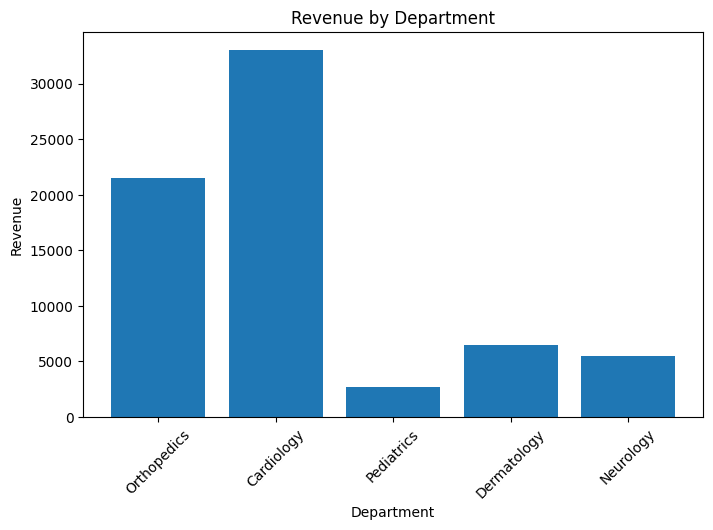

In [0]:
import pandas as pd
import matplotlib.pyplot as plt

dept_rev = full_df.groupBy("department"
).agg( sum("final_bill").alias("revenue"))

dept_rev = dept_rev.toPandas()

plt.figure(figsize=(8,5))
plt.bar(dept_rev['department'], dept_rev['revenue'])
plt.xlabel('Department')
plt.ylabel('Revenue')
plt.title('Revenue by Department')
plt.xticks(rotation=45)
plt.show()

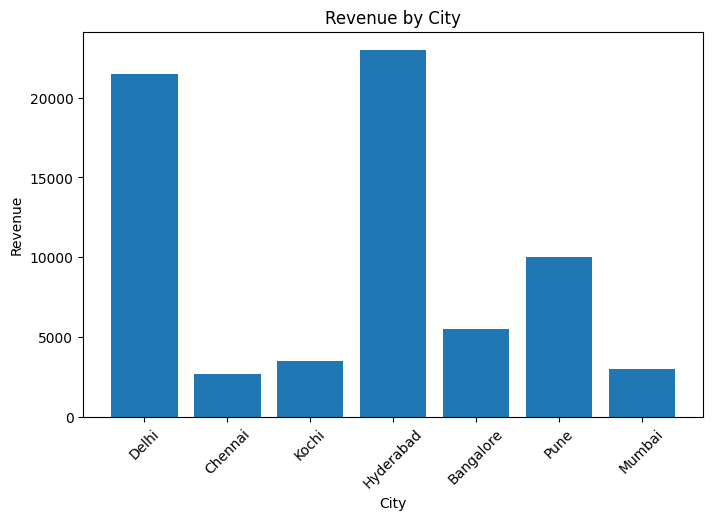

In [0]:

city_rev = full_df.groupBy('city').agg(sum('final_bill').alias('revenue'))

city_rev = city_rev.toPandas()

plt.figure(figsize=(8,5))
plt.bar(city_rev['city'], city_rev['revenue'])
plt.xlabel('City')
plt.ylabel('Revenue')
plt.title('Revenue by City')
plt.xticks(rotation=45)
plt.show()

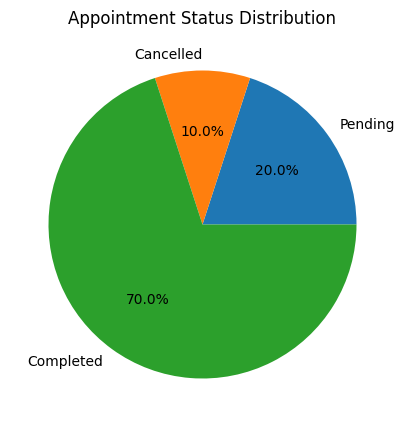

In [0]:
status_df = full_df.groupBy('status').count()

status_df = status_df.toPandas()

plt.figure(figsize=(8,5))
plt.pie(
    status_df["count"],
    labels=status_df["status"],
    autopct="%1.1f%%"
)
plt.title('Appointment Status Distribution')
plt.show()
     

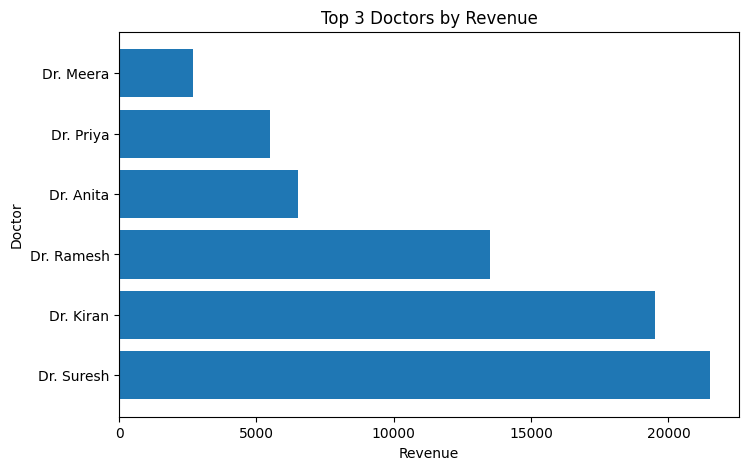

In [0]:
doc_rev = full_df.groupBy(
    'doctor_id',
    'doctor_name'
).agg(sum('final_bill').alias('revenue')).orderBy(desc('revenue')
)

doc_rev = doc_rev.toPandas()

plt.figure(figsize=(8,5))
plt.barh(doc_rev['doctor_name'], doc_rev['revenue'])
plt.xlabel('Revenue')
plt.ylabel('Doctor')
plt.title('Top 3 Doctors by Revenue')
plt.show()
     

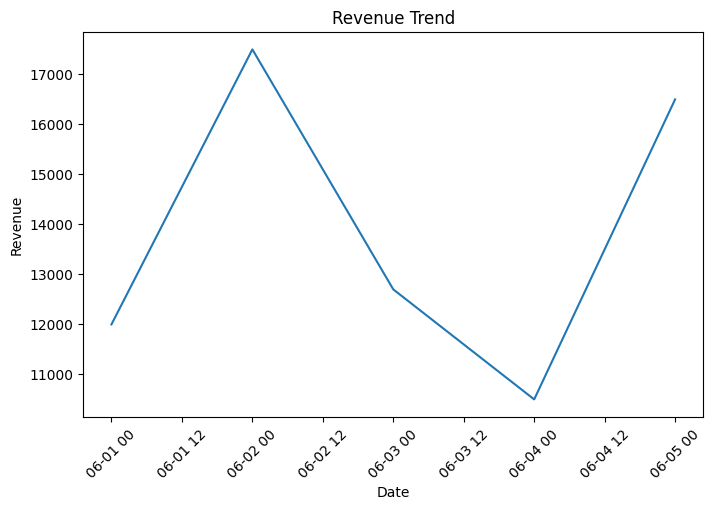

In [0]:
rev_trend = full_df.groupBy(
    "appointment_date"
).agg(sum("final_bill").alias("revenue")).orderBy('appointment_date')

rev_trend = rev_trend.toPandas()

plt.figure(figsize=(8,5))
plt.plot(rev_trend["appointment_date"],rev_trend["revenue"])
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.title("Revenue Trend")
plt.xticks(rotation=45)
plt.show()

In [0]:
full_df.write \
    .format("delta") \
    .mode("overwrite") \
    .saveAsTable("hospital_managed")

In [0]:
%sql
SELECT * FROM hospital_managed;

doctor_id,patient_id,patient_name,city,state,age,gender,insurance_status,contact,preferred_hospital,appointment_id,appointment_date,diagnosis,bill_amount,status,doctor_name,department,doctor_city,consultation_fee,final_bill,appointment_month,patient_age_group
D106,P101,Rahul Sharma,Hyderabad,Telangana,35,Male,Active,"List(rahul@mail.com, 9876500011)",Apollo Hospital,A1009,2026-06-05,Cardiac Review,6500,Completed,Dr. Kiran,Cardiology,Hyderabad,3000,9500,2026-06,Adult
D102,P102,Priya Reddy,Bangalore,Karnataka,29,Female,Active,"List(priya@mail.com, 9876500012)",Yashoda Hospital,A1002,2026-06-01,Migraine,3500,Completed,Dr. Priya,Neurology,Bangalore,2000,5500,2026-06,Young
D103,P103,Amit Kumar,Mumbai,Maharashtra,42,Male,Inactive,null,null,A1003,2026-06-02,Skin Allergy,2000,Pending,Dr. Anita,Dermatology,Chennai,1000,3000,2026-06,Adult
D104,P104,Sneha Patel,Delhi,Delhi,31,Female,Active,"List(sneha@mail.com, 9876500014)",Care Hospital,A1010,2026-06-05,Back Pain,4500,Cancelled,Dr. Suresh,Orthopedics,Mumbai,2500,7000,2026-06,Adult
D105,P105,Farhan Ali,Chennai,Tamil Nadu,55,Male,Active,null,null,A1005,2026-06-03,Fever,1500,Completed,Dr. Meera,Pediatrics,Delhi,1200,2700,2026-06,Senior
D106,P106,Neha Singh,Pune,Maharashtra,38,Female,Inactive,null,null,A1006,2026-06-03,Heart Checkup,7000,Completed,Dr. Kiran,Cardiology,Hyderabad,3000,10000,2026-06,Adult
D101,P107,Arjun Verma,Hyderabad,Telangana,26,Male,Active,null,null,A1007,2026-06-04,Chest Pain,5500,Completed,Dr. Ramesh,Cardiology,Hyderabad,1500,7000,2026-06,Young
D103,P108,Meera Nair,Kochi,Kerala,48,Female,Active,"List(meera@mail.com, 9876500018)",Apollo Hospital,A1008,2026-06-04,Skin Infection,2500,Pending,Dr. Anita,Dermatology,Chennai,1000,3500,2026-06,Adult
D101,P101,Rahul Sharma,Hyderabad,Telangana,35,Male,Active,"List(rahul@mail.com, 9876500011)",Apollo Hospital,A1001,2026-06-01,Heart Checkup,5000,Completed,Dr. Ramesh,Cardiology,Hyderabad,1500,6500,2026-06,Adult
D104,P104,Sneha Patel,Delhi,Delhi,31,Female,Active,"List(sneha@mail.com, 9876500014)",Care Hospital,A1004,2026-06-02,Fracture,12000,Completed,Dr. Suresh,Orthopedics,Mumbai,2500,14500,2026-06,Adult


In [0]:
full_df.createOrReplaceTempView("hospital_temp")

In [0]:
%sql
SELECT * FROM hospital_temp;

doctor_id,patient_id,patient_name,city,state,age,gender,insurance_status,contact,preferred_hospital,appointment_id,appointment_date,diagnosis,bill_amount,status,doctor_name,department,doctor_city,consultation_fee,final_bill,appointment_month,patient_age_group
D106,P101,Rahul Sharma,Hyderabad,Telangana,35,Male,Active,"List(rahul@mail.com, 9876500011)",Apollo Hospital,A1009,2026-06-05,Cardiac Review,6500,Completed,Dr. Kiran,Cardiology,Hyderabad,3000,9500,2026-06,Adult
D102,P102,Priya Reddy,Bangalore,Karnataka,29,Female,Active,"List(priya@mail.com, 9876500012)",Yashoda Hospital,A1002,2026-06-01,Migraine,3500,Completed,Dr. Priya,Neurology,Bangalore,2000,5500,2026-06,Young
D103,P103,Amit Kumar,Mumbai,Maharashtra,42,Male,Inactive,null,null,A1003,2026-06-02,Skin Allergy,2000,Pending,Dr. Anita,Dermatology,Chennai,1000,3000,2026-06,Adult
D104,P104,Sneha Patel,Delhi,Delhi,31,Female,Active,"List(sneha@mail.com, 9876500014)",Care Hospital,A1010,2026-06-05,Back Pain,4500,Cancelled,Dr. Suresh,Orthopedics,Mumbai,2500,7000,2026-06,Adult
D105,P105,Farhan Ali,Chennai,Tamil Nadu,55,Male,Active,null,null,A1005,2026-06-03,Fever,1500,Completed,Dr. Meera,Pediatrics,Delhi,1200,2700,2026-06,Senior
D106,P106,Neha Singh,Pune,Maharashtra,38,Female,Inactive,null,null,A1006,2026-06-03,Heart Checkup,7000,Completed,Dr. Kiran,Cardiology,Hyderabad,3000,10000,2026-06,Adult
D101,P107,Arjun Verma,Hyderabad,Telangana,26,Male,Active,null,null,A1007,2026-06-04,Chest Pain,5500,Completed,Dr. Ramesh,Cardiology,Hyderabad,1500,7000,2026-06,Young
D103,P108,Meera Nair,Kochi,Kerala,48,Female,Active,"List(meera@mail.com, 9876500018)",Apollo Hospital,A1008,2026-06-04,Skin Infection,2500,Pending,Dr. Anita,Dermatology,Chennai,1000,3500,2026-06,Adult
D101,P101,Rahul Sharma,Hyderabad,Telangana,35,Male,Active,"List(rahul@mail.com, 9876500011)",Apollo Hospital,A1001,2026-06-01,Heart Checkup,5000,Completed,Dr. Ramesh,Cardiology,Hyderabad,1500,6500,2026-06,Adult
D104,P104,Sneha Patel,Delhi,Delhi,31,Female,Active,"List(sneha@mail.com, 9876500014)",Care Hospital,A1004,2026-06-02,Fracture,12000,Completed,Dr. Suresh,Orthopedics,Mumbai,2500,14500,2026-06,Adult


In [0]:
patients_df.printSchema()
display(patients_df)

root
 |-- patient_id: string (nullable = true)
 |-- patient_name: string (nullable = true)
 |-- city: string (nullable = true)
 |-- state: string (nullable = true)
 |-- age: integer (nullable = true)
 |-- gender: string (nullable = true)
 |-- insurance_status: string (nullable = true)



patient_id,patient_name,city,state,age,gender,insurance_status
P101,Rahul Sharma,Hyderabad,Telangana,35,Male,Active
P102,Priya Reddy,Bangalore,Karnataka,29,Female,Active
P103,Amit Kumar,Mumbai,Maharashtra,42,Male,Inactive
P104,Sneha Patel,Delhi,Delhi,31,Female,Active
P105,Farhan Ali,Chennai,Tamil Nadu,55,Male,Active
P106,Neha Singh,Pune,Maharashtra,38,Female,Inactive
P107,Arjun Verma,Hyderabad,Telangana,26,Male,Active
P108,Meera Nair,Kochi,Kerala,48,Female,Active


In [0]:
doctors_df.printSchema()
display(doctors_df)

root
 |-- doctor_id: string (nullable = true)
 |-- doctor_name: string (nullable = true)
 |-- department: string (nullable = true)
 |-- city: string (nullable = true)
 |-- consultation_fee: integer (nullable = true)



doctor_id,doctor_name,department,city,consultation_fee
D101,Dr. Ramesh,Cardiology,Hyderabad,1500
D102,Dr. Priya,Neurology,Bangalore,2000
D103,Dr. Anita,Dermatology,Chennai,1000
D104,Dr. Suresh,Orthopedics,Mumbai,2500
D105,Dr. Meera,Pediatrics,Delhi,1200
D106,Dr. Kiran,Cardiology,Hyderabad,3000


In [0]:
appointments_df.printSchema()
display(appointments_df)

root
 |-- appointment_id: string (nullable = true)
 |-- patient_id: string (nullable = true)
 |-- doctor_id: string (nullable = true)
 |-- appointment_date: date (nullable = true)
 |-- diagnosis: string (nullable = true)
 |-- bill_amount: integer (nullable = true)
 |-- status: string (nullable = true)



appointment_id,patient_id,doctor_id,appointment_date,diagnosis,bill_amount,status
A1001,P101,D101,2026-06-01,Heart Checkup,5000,Completed
A1002,P102,D102,2026-06-01,Migraine,3500,Completed
A1003,P103,D103,2026-06-02,Skin Allergy,2000,Pending
A1004,P104,D104,2026-06-02,Fracture,12000,Completed
A1005,P105,D105,2026-06-03,Fever,1500,Completed
A1006,P106,D106,2026-06-03,Heart Checkup,7000,Completed
A1007,P107,D101,2026-06-04,Chest Pain,5500,Completed
A1008,P108,D103,2026-06-04,Skin Infection,2500,Pending
A1009,P101,D106,2026-06-05,Cardiac Review,6500,Completed
A1010,P104,D104,2026-06-05,Back Pain,4500,Cancelled


In [0]:
preferences_df.printSchema()
display(preferences_df)

root
 |-- contact: struct (nullable = true)
 |    |-- email: string (nullable = true)
 |    |-- phone: string (nullable = true)
 |-- patient_id: string (nullable = true)
 |-- preferred_hospital: string (nullable = true)



contact,patient_id,preferred_hospital
"List(rahul@mail.com, 9876500011)",P101,Apollo Hospital
"List(priya@mail.com, 9876500012)",P102,Yashoda Hospital
"List(sneha@mail.com, 9876500014)",P104,Care Hospital
"List(meera@mail.com, 9876500018)",P108,Apollo Hospital


In [0]:
flat.printSchema()
display(flat)

root
 |-- patient_id: string (nullable = true)
 |-- preferred_hospital: string (nullable = true)
 |-- phone: string (nullable = true)
 |-- email: string (nullable = true)



patient_id,preferred_hospital,phone,email
P101,Apollo Hospital,9876500011,rahul@mail.com
P102,Yashoda Hospital,9876500012,priya@mail.com
P104,Care Hospital,9876500014,sneha@mail.com
P108,Apollo Hospital,9876500018,meera@mail.com


In [0]:
healthcare_df.printSchema()
display(healthcare_df)

root
 |-- doctor_id: string (nullable = true)
 |-- patient_id: string (nullable = true)
 |-- appointment_id: string (nullable = true)
 |-- appointment_date: date (nullable = true)
 |-- diagnosis: string (nullable = true)
 |-- bill_amount: integer (nullable = true)
 |-- status: string (nullable = true)
 |-- patient_name: string (nullable = true)
 |-- patient_city: string (nullable = true)
 |-- state: string (nullable = true)
 |-- age: integer (nullable = true)
 |-- gender: string (nullable = true)
 |-- insurance_status: string (nullable = true)
 |-- doctor_name: string (nullable = true)
 |-- department: string (nullable = true)
 |-- doctor_city: string (nullable = true)
 |-- consultation_fee: integer (nullable = true)
 |-- final_bill: integer (nullable = true)
 |-- appointment_month: string (nullable = true)
 |-- patient_age_group: string (nullable = false)



doctor_id,patient_id,appointment_id,appointment_date,diagnosis,bill_amount,status,patient_name,patient_city,state,age,gender,insurance_status,doctor_name,department,doctor_city,consultation_fee,final_bill,appointment_month,patient_age_group
D101,P101,A1001,2026-06-01,Heart Checkup,5000,Completed,Rahul Sharma,Hyderabad,Telangana,35,Male,Active,Dr. Ramesh,Cardiology,Hyderabad,1500,6500,2026-06,Adult
D102,P102,A1002,2026-06-01,Migraine,3500,Completed,Priya Reddy,Bangalore,Karnataka,29,Female,Active,Dr. Priya,Neurology,Bangalore,2000,5500,2026-06,Young
D103,P103,A1003,2026-06-02,Skin Allergy,2000,Pending,Amit Kumar,Mumbai,Maharashtra,42,Male,Inactive,Dr. Anita,Dermatology,Chennai,1000,3000,2026-06,Adult
D104,P104,A1004,2026-06-02,Fracture,12000,Completed,Sneha Patel,Delhi,Delhi,31,Female,Active,Dr. Suresh,Orthopedics,Mumbai,2500,14500,2026-06,Adult
D105,P105,A1005,2026-06-03,Fever,1500,Completed,Farhan Ali,Chennai,Tamil Nadu,55,Male,Active,Dr. Meera,Pediatrics,Delhi,1200,2700,2026-06,Senior
D106,P106,A1006,2026-06-03,Heart Checkup,7000,Completed,Neha Singh,Pune,Maharashtra,38,Female,Inactive,Dr. Kiran,Cardiology,Hyderabad,3000,10000,2026-06,Adult
D101,P107,A1007,2026-06-04,Chest Pain,5500,Completed,Arjun Verma,Hyderabad,Telangana,26,Male,Active,Dr. Ramesh,Cardiology,Hyderabad,1500,7000,2026-06,Young
D103,P108,A1008,2026-06-04,Skin Infection,2500,Pending,Meera Nair,Kochi,Kerala,48,Female,Active,Dr. Anita,Dermatology,Chennai,1000,3500,2026-06,Adult
D106,P101,A1009,2026-06-05,Cardiac Review,6500,Completed,Rahul Sharma,Hyderabad,Telangana,35,Male,Active,Dr. Kiran,Cardiology,Hyderabad,3000,9500,2026-06,Adult
D104,P104,A1010,2026-06-05,Back Pain,4500,Cancelled,Sneha Patel,Delhi,Delhi,31,Female,Active,Dr. Suresh,Orthopedics,Mumbai,2500,7000,2026-06,Adult


In [0]:
full_df.printSchema()
display(full_df)

root
 |-- doctor_id: string (nullable = true)
 |-- patient_id: string (nullable = true)
 |-- patient_name: string (nullable = true)
 |-- city: string (nullable = true)
 |-- state: string (nullable = true)
 |-- age: integer (nullable = true)
 |-- gender: string (nullable = true)
 |-- insurance_status: string (nullable = true)
 |-- contact: struct (nullable = true)
 |    |-- email: string (nullable = true)
 |    |-- phone: string (nullable = true)
 |-- preferred_hospital: string (nullable = true)
 |-- appointment_id: string (nullable = true)
 |-- appointment_date: date (nullable = true)
 |-- diagnosis: string (nullable = true)
 |-- bill_amount: integer (nullable = true)
 |-- status: string (nullable = true)
 |-- doctor_name: string (nullable = true)
 |-- department: string (nullable = true)
 |-- doctor_city: string (nullable = true)
 |-- consultation_fee: integer (nullable = true)
 |-- final_bill: integer (nullable = true)
 |-- appointment_month: string (nullable = true)
 |-- patient_age

doctor_id,patient_id,patient_name,city,state,age,gender,insurance_status,contact,preferred_hospital,appointment_id,appointment_date,diagnosis,bill_amount,status,doctor_name,department,doctor_city,consultation_fee,final_bill,appointment_month,patient_age_group
D106,P101,Rahul Sharma,Hyderabad,Telangana,35,Male,Active,"List(rahul@mail.com, 9876500011)",Apollo Hospital,A1009,2026-06-05,Cardiac Review,6500,Completed,Dr. Kiran,Cardiology,Hyderabad,3000,9500,2026-06,Adult
D102,P102,Priya Reddy,Bangalore,Karnataka,29,Female,Active,"List(priya@mail.com, 9876500012)",Yashoda Hospital,A1002,2026-06-01,Migraine,3500,Completed,Dr. Priya,Neurology,Bangalore,2000,5500,2026-06,Young
D103,P103,Amit Kumar,Mumbai,Maharashtra,42,Male,Inactive,null,null,A1003,2026-06-02,Skin Allergy,2000,Pending,Dr. Anita,Dermatology,Chennai,1000,3000,2026-06,Adult
D104,P104,Sneha Patel,Delhi,Delhi,31,Female,Active,"List(sneha@mail.com, 9876500014)",Care Hospital,A1010,2026-06-05,Back Pain,4500,Cancelled,Dr. Suresh,Orthopedics,Mumbai,2500,7000,2026-06,Adult
D105,P105,Farhan Ali,Chennai,Tamil Nadu,55,Male,Active,null,null,A1005,2026-06-03,Fever,1500,Completed,Dr. Meera,Pediatrics,Delhi,1200,2700,2026-06,Senior
D106,P106,Neha Singh,Pune,Maharashtra,38,Female,Inactive,null,null,A1006,2026-06-03,Heart Checkup,7000,Completed,Dr. Kiran,Cardiology,Hyderabad,3000,10000,2026-06,Adult
D101,P107,Arjun Verma,Hyderabad,Telangana,26,Male,Active,null,null,A1007,2026-06-04,Chest Pain,5500,Completed,Dr. Ramesh,Cardiology,Hyderabad,1500,7000,2026-06,Young
D103,P108,Meera Nair,Kochi,Kerala,48,Female,Active,"List(meera@mail.com, 9876500018)",Apollo Hospital,A1008,2026-06-04,Skin Infection,2500,Pending,Dr. Anita,Dermatology,Chennai,1000,3500,2026-06,Adult
D101,P101,Rahul Sharma,Hyderabad,Telangana,35,Male,Active,"List(rahul@mail.com, 9876500011)",Apollo Hospital,A1001,2026-06-01,Heart Checkup,5000,Completed,Dr. Ramesh,Cardiology,Hyderabad,1500,6500,2026-06,Adult
D104,P104,Sneha Patel,Delhi,Delhi,31,Female,Active,"List(sneha@mail.com, 9876500014)",Care Hospital,A1004,2026-06-02,Fracture,12000,Completed,Dr. Suresh,Orthopedics,Mumbai,2500,14500,2026-06,Adult
